# Does virtue pay? Risk-adjusted performance of ESG vs traditional ETFs

*A data-driven analysis for BEE2041: Data Science in Economics*

---

## 1. Introduction

ESG investing has become almost impossible to ignore. Driven by climate concerns, regulatory pressure, and changing investor preferences, the assets in ESG-focused funds grew from a small corner of the industry to roughly $30 trillion by the mid-2020s. These funds are usually marketed as offering both ethical alignment *and* competitive financial performance, in a kind of best-of-both-worlds pitch.

The thing is, the academic literature is genuinely split on whether ESG investing actually outperforms traditional portfolios on a risk-adjusted basis. There are basically two competing views. The first says ESG screening should *help* returns: forward-looking risks like climate litigation, carbon taxes and governance scandals are arguably mispriced by the broader market, and ESG funds avoid the firms most exposed to them. Some studies also point to lower downside risk in stress periods. The second view, which comes straight out of textbook portfolio theory, says ESG screening should *hurt* returns: any binding investment constraint shrinks the opportunity set, and a smaller opportunity set cannot beat a larger one in risk-adjusted terms. So the question is: which one actually shows up in the data?

I wanted to explore whether ESG investments really outperform traditional portfolios in terms of returns, volatility, and risk-adjusted performance. I initially considered using individual stocks, but I switched to ETFs to avoid stock-picking and selection bias and keep the comparison clean. The final sample is six exchange-traded funds: three ESG-focused (ESGU, SUSA, ICLN) and three broad-market (SPY, VTI, DIA), with daily price data from January 2019 to December 2025. I evaluate mean returns, volatility, Sharpe ratios, and CAPM alpha, plus a Fama–French three-factor extension. The research question is:

> **Do ESG investments deliver superior risk-adjusted returns compared to traditional portfolios? In particular, once we strip out exposure to common risk factors, do ESG ETFs produce positive *alpha* relative to the market?**

I tackle this in three layers: headline numbers (cumulative growth, volatility, Sharpe ratios), a CAPM regression that splits each ETF's excess return into market beta and alpha, and a Fama–French three-factor regression that adds size and value factors. The reasoning behind the third step is that an alpha that disappears once you control for known styles was never really alpha to begin with. I also run a paired t-test on the daily ESG-minus-traditional return to test whether the average gap is zero.

The audience is anyone curious about whether sustainable investing is a serious financial proposition or mostly a marketing veneer. No programming background is assumed.

## 2. Data

The dataset is built entirely from public sources via code; nothing was downloaded by hand. I wanted the project to be fully reproducible, so anyone can clone the repository and run the four scripts in `scripts/` to regenerate every number and chart.

**Equity returns.** Daily adjusted-close prices for six ETFs are pulled from Yahoo Finance through the `yfinance` Python package. *Adjusted* means the price series is back-adjusted for dividends and splits, so the simple percentage change between consecutive days is a true total return.

**ESG basket.** *ESGU* (iShares ESG Aware MSCI USA) is a broad US large-cap fund that tilts towards higher-rated ESG firms while maintaining sector weights close to those of the parent index. *SUSA* (iShares MSCI USA ESG Select) is a stricter best-in-class sustainability fund. *ICLN* (iShares Global Clean Energy) is a thematic fund concentrated in renewable-energy producers, by far the most "green" of the three.

**Traditional basket.** *SPY* (S&P 500), *VTI* (Vanguard Total Stock Market), and *DIA* (Dow Jones Industrial Average): three different cuts of the broad US equity market with no sustainability screen.

**Risk factors.** Daily values for the Fama–French three factors (Mkt-RF, SMB, HML) and the daily US risk-free rate come from Kenneth R. French's data library via `pandas-datareader`. One challenge here was that the factor data and the ETF prices use slightly different trading calendars in some edge cases ( mostly half-day ), so I had to align them at the intersection of the two date indices before running anything.

**Sample window.** January 2019 through December 2025: roughly 1,750 trading days per series, covering the late-cycle 2019 rally, the COVID crash, and the 2022 inflation shock.

The cell below loads the cleaned data generated by the project's scripts.

In [1]:
# Load the cleaned project data. Run scripts/fetch_data.py and
# scripts/clean_data.py first if these CSVs do not exist yet.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import pandas as pd
from config import (PROCESSED_DIR, OUTPUTS_DIR, PLOTS_DIR,
                    ESG_TICKERS, TRADITIONAL_TICKERS)

prices  = pd.read_csv(PROCESSED_DIR / "prices.csv",
                      parse_dates=["Date"], index_col="Date")
returns = pd.read_csv(PROCESSED_DIR / "returns.csv",
                      parse_dates=["Date"], index_col="Date")
factors = pd.read_csv(PROCESSED_DIR / "factors.csv",
                      parse_dates=["Date"], index_col="Date")

print(f"Sample: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Trading days: {len(returns):,}")
print(f"Tickers: {list(returns.columns)}")
returns.head().round(4)


Sample: 2019-01-03 to 2025-12-30
Trading days: 1,758
Tickers: ['ESGU', 'SUSA', 'ICLN', 'SPY', 'VTI', 'DIA']


,ESGU,SUSA,ICLN,SPY,VTI,DIA
Date,,,,,,
2019-01-03,-0.0232,-0.0261,-0.0084,-0.0239,-0.0232,-0.0285
2019-01-04,0.0365,0.0345,0.0303,0.0335,0.0331,0.0333
2019-01-07,0.0065,0.0108,0.0082,0.0079,0.0101,0.0046
2019-01-08,0.0113,0.0104,0.0117,0.0094,0.0103,0.0109
2019-01-09,0.0027,0.0035,0.0081,0.0047,0.0047,0.0042


## 3. Methodology

### 3.1 Returns and risk

I use **simple daily returns** $r_t = P_t / P_{t-1} - 1$, annualized the conventional way (multiply the mean by 252 trading days, the standard deviation by $\sqrt{252}$).

The **Sharpe ratio** is the annualized mean of *excess* returns (return minus the risk-free rate) divided by the annualized standard deviation. It's the cleanest single-number measure of compensation per unit of total risk.

### 3.2 CAPM

The CAPM regression is

$$r_{i,t} - r_{f,t} \;=\; \alpha_i \;+\; \beta_i\,(r_{m,t} - r_{f,t}) \;+\; \varepsilon_{i,t}.$$

In words: each ETF's excess return is split into a constant ($\alpha$) and a part that moves one-for-one with the market times a sensitivity ($\beta$). A beta near 1 means the fund moves with the market; below 1 means it is defensive; above 1 means it amplifies market moves. **Alpha is the part of return that the market cannot explain.** A statistically significant positive alpha is the closest thing in finance to a free lunch.

### 3.3 Fama–French three-factor

The CAPM is famously incomplete: even random portfolios show up with non-zero "alpha" if their style is unusual. Fama and French extend it by adding two empirical risk factors:

$$r_{i,t} - r_{f,t} \;=\; \alpha_i \;+\; \beta_{M}\,\text{MKT}_t \;+\; \beta_{S}\,\text{SMB}_t \;+\; \beta_{H}\,\text{HML}_t \;+\; \varepsilon_{i,t},$$

where SMB ("small minus big") captures the historical premium for small-cap stocks and HML ("high minus low") captures the value-versus-growth premium. If a fund's CAPM alpha shrinks once these factors are added, the apparent skill was just a tilt toward small or value stocks.

### 3.4 Inference

I report **Newey–West (HAC)** standard errors with five lags, the standard fix for serial correlation and heteroskedasticity in the empirical-asset-pricing literature. A paired t-test on the daily ESG-minus-traditional basket return checks whether the average gap is distinguishable from zero.

## 4. Results

### 4.1 Cumulative returns: who came out ahead?

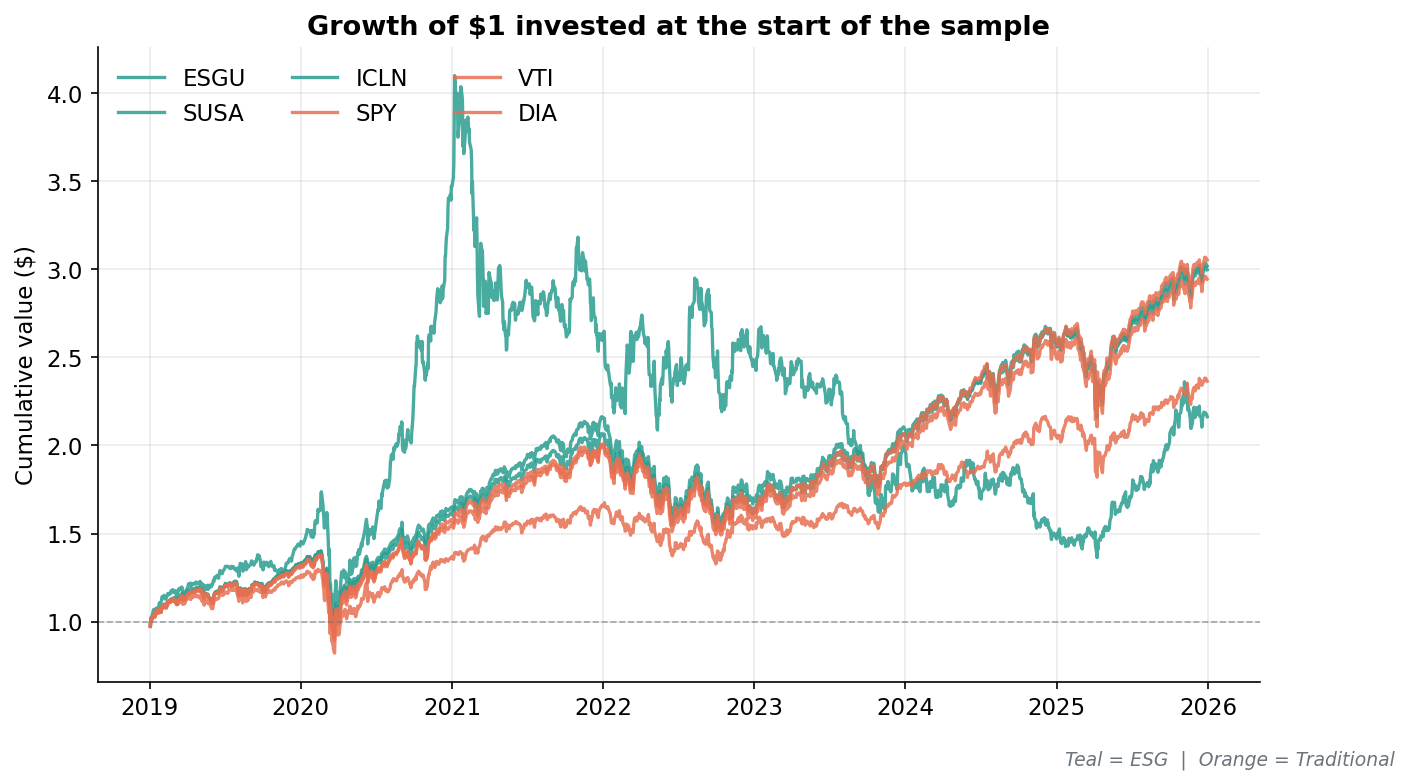

In [2]:
from IPython.display import Image, display
display(Image(PLOTS_DIR / "01_cumulative_returns.png"))


**Figure 1.** Growth of one US dollar invested at the start of the sample. Teal lines are the ESG ETFs; orange lines are the traditional ones.

The first thing to notice is that the broad-market funds (SPY, VTI, DIA) and the broad-ESG funds (ESGU, SUSA) trace nearly identical paths. That's not an accident: ESGU and SUSA are designed to track the parent US large-cap universe with only modest tilts. **The eye-catching line is ICLN, the clean-energy ETF.** It went on a spectacular run during the 2020-21 green-investment boom (at peak it was up roughly 300% on its starting value) before giving back most of those gains in the 2022 rate shock. By the end of the sample, ICLN sits *below* the broad-market funds.

This is the central tension of the post. Looking at Figure 1, you might conclude that ESG "worked" until 2021 and "failed" after. A more careful reading is that ICLN is a *concentrated, high-vol sector bet* sensitive to interest rates. Lumping it with diversified ESG funds confuses two very different products.

### 4.2 Volatility: ESG is not a smooth ride.

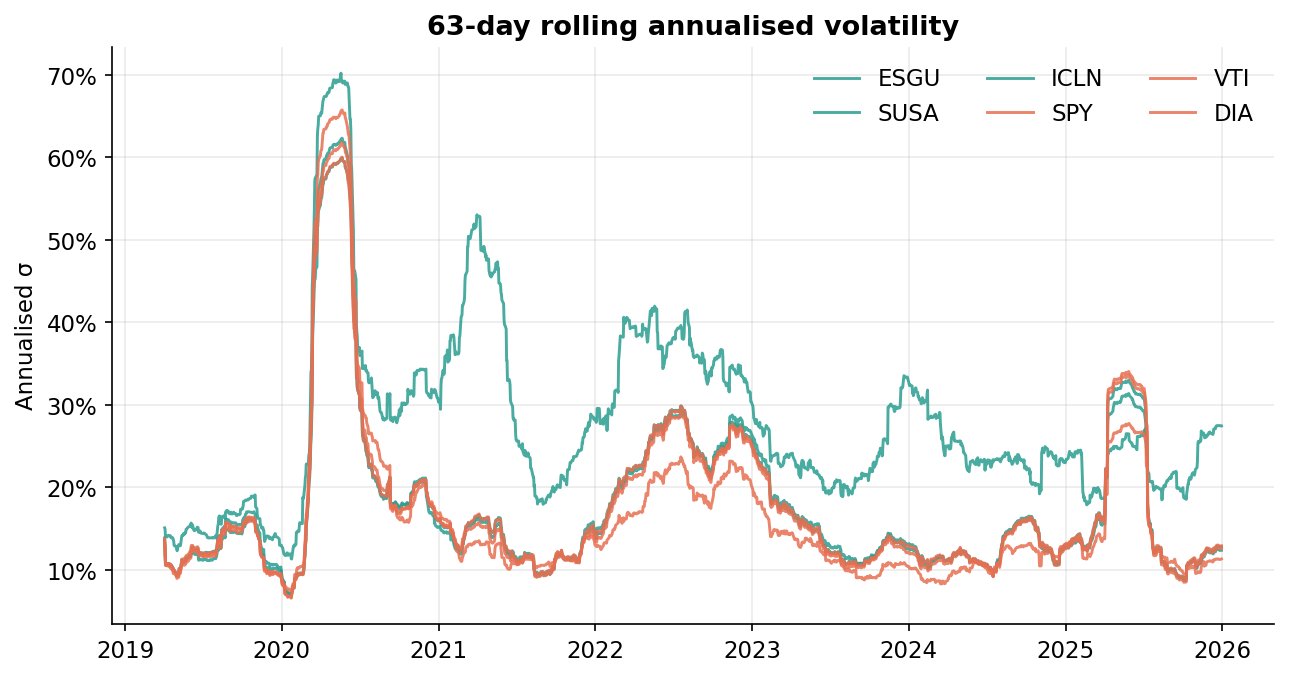

In [3]:
display(Image(PLOTS_DIR / "02_rolling_volatility.png"))


**Figure 2.** Sixty-three-day rolling annualized volatility (one quarter of trading days).

All six funds spike together in the COVID crash of March 2020. Risk is contagious in a crisis. The interesting structural pattern is the persistent gap between ICLN (25–35% annualised) and everything else (15–22%). A clean-energy fund delivers roughly **fifty percent more volatility** than a broad-market fund. ESGU and SUSA, by contrast, are visually indistinguishable from SPY/VTI/DIA. Their tilt is too modest to change the risk profile.

### 4.3 The risk–return picture in one chart.

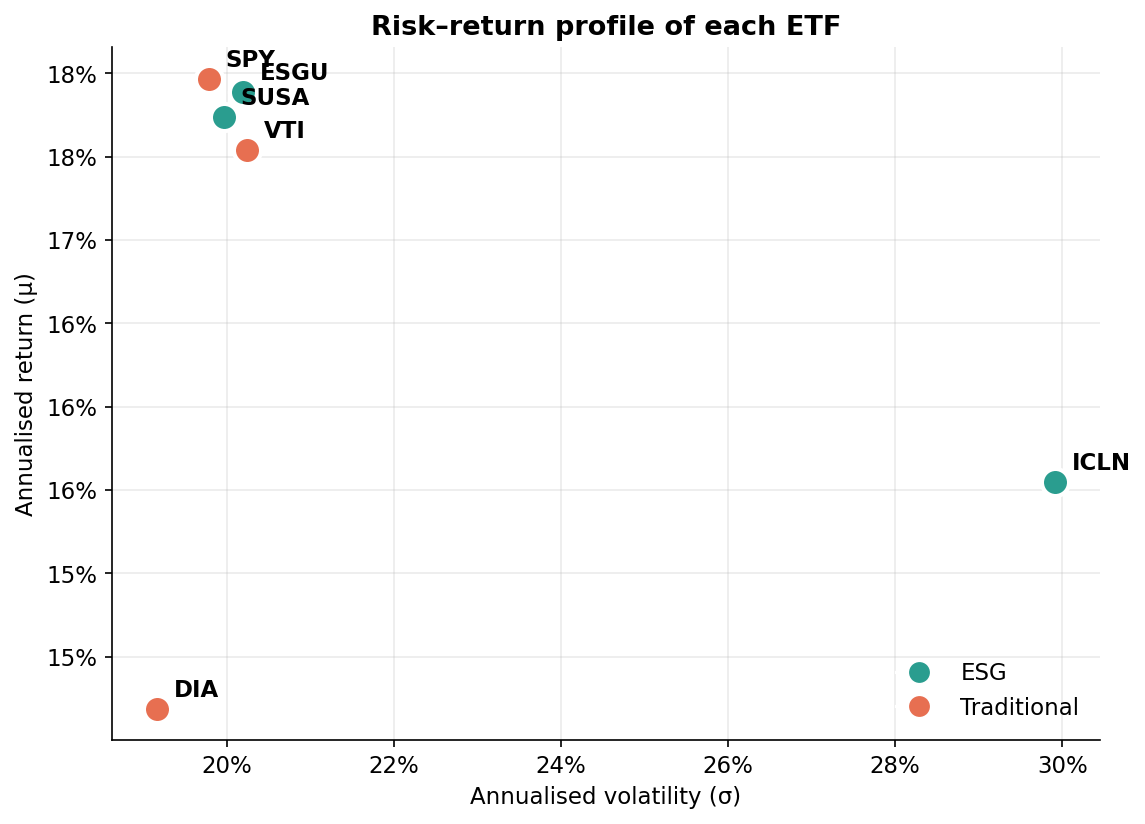

In [4]:
display(Image(PLOTS_DIR / "04_risk_return_scatter.png"))


**Figure 3.** Annualised return plotted against annualised volatility for each ETF.

The five non-ICLN funds cluster tightly: very similar risk, very similar return. ICLN sits well to the right (more risky) and slightly above (somewhat higher return). A higher absolute return, but not obviously a better deal once that extra risk is taken into account. This is exactly what the Sharpe ratio is built to measure.

### 4.4 Summary statistics and the Sharpe table

In [5]:
desc = pd.read_csv(OUTPUTS_DIR / "descriptive_stats.csv", index_col="Ticker")

display_df = desc.copy()
display_df["Ann. Return"]      = (display_df["Ann. Return"]*100).round(2).astype(str) + "%"
display_df["Ann. Volatility"]  = (display_df["Ann. Volatility"]*100).round(2).astype(str) + "%"
display_df["Sharpe"]           = display_df["Sharpe"].round(3)
display_df["Sharpe 95% CI low"]  = display_df["Sharpe 95% CI low"].round(3)
display_df["Sharpe 95% CI high"] = display_df["Sharpe 95% CI high"].round(3)
display_df


,Group,Ann. Return,Ann. Volatility,Sharpe,Sharpe 95% CI low,Sharpe 95% CI high
Ticker,,,,,,
ESGU,ESG,17.89%,20.2%,0.748,0.007,1.494
SUSA,ESG,17.74%,19.97%,0.749,-0.001,1.484
ICLN,ESG,15.55%,29.91%,0.427,-0.335,1.163
SPY,Traditional,17.97%,19.78%,0.767,0.026,1.514
VTI,Traditional,17.54%,20.25%,0.729,-0.015,1.475
DIA,Traditional,14.19%,19.16%,0.595,-0.137,1.336


**Table 1.** Per-ETF descriptive statistics. Sharpe ratios are reported with a bootstrap 95% confidence interval based on 5,000 resamples.

The Sharpe ratios for the broad-ESG and broad-traditional funds are statistically indistinguishable. Every confidence interval overlaps with every other. ICLN's higher mean return is largely cancelled by its much higher volatility, leaving it with a Sharpe ratio that is no better, and arguably worse, than that of a plain S&P 500 tracker.

### 4.5 Distribution of daily returns

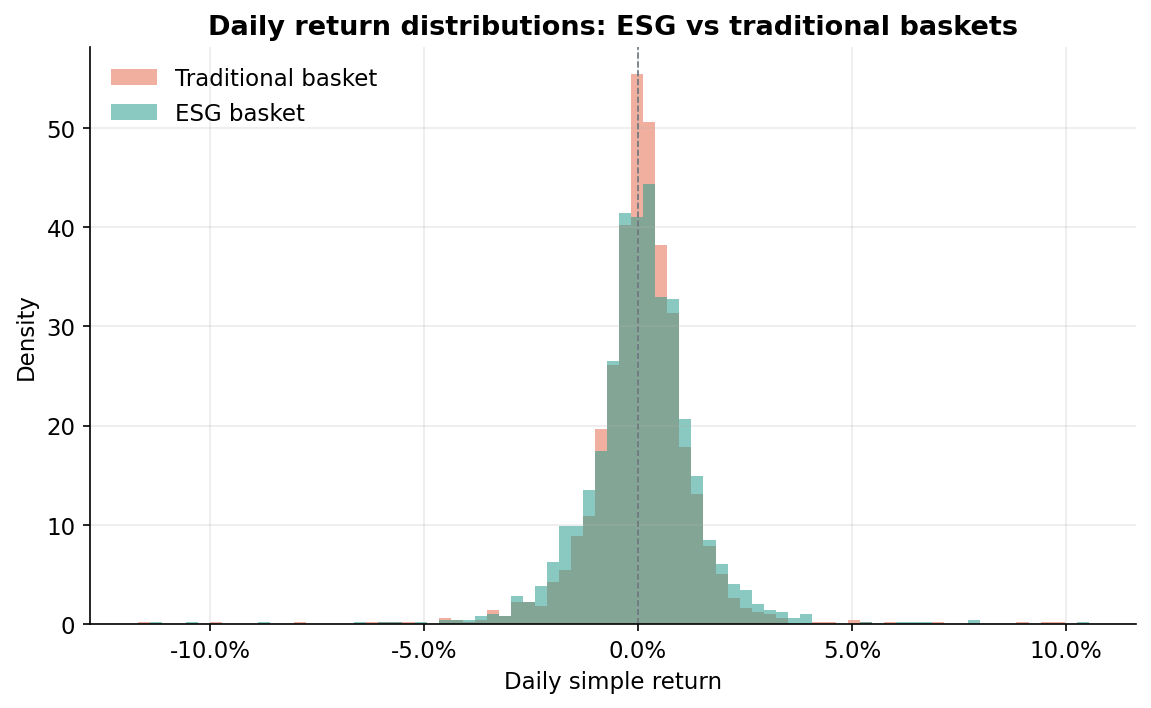

In [6]:
display(Image(PLOTS_DIR / "03_return_distributions.png"))


**Figure 4.** Histogram of daily returns for the equally-weighted ESG basket and the equally-weighted traditional basket.

The two distributions are visually almost identical: same centre, same width, same fat tails. A formal t-test confirms what the eye sees.

In [7]:
ttest = pd.read_csv(OUTPUTS_DIR / "basket_ttest.csv", index_col=0)["value"]
print(f"Mean daily ESG-Traditional gap : {ttest['mean_diff_daily']*1e4:6.2f} bps")
print(f"Annualised:                      {ttest['mean_diff_annual']*100:6.2f} pp")
print(f"t-statistic:                     {ttest['t_stat']:6.3f}")
print(f"p-value:                         {ttest['p_value']:6.4f}")
print(f"Number of daily observations:    {int(ttest['n']):,}")


Mean daily ESG-Traditional gap :   0.20 bps
Annualised:                        0.49 pp
t-statistic:                      0.159
p-value:                         0.8736
Number of daily observations:    1,758


**Test result.** A paired t-test on the daily ESG-basket return minus the daily traditional-basket return cannot reject the null hypothesis of zero mean difference at conventional significance levels. **There is no measurable, systematic outperformance, in either direction.**

### 4.6 CAPM regressions: alpha and beta

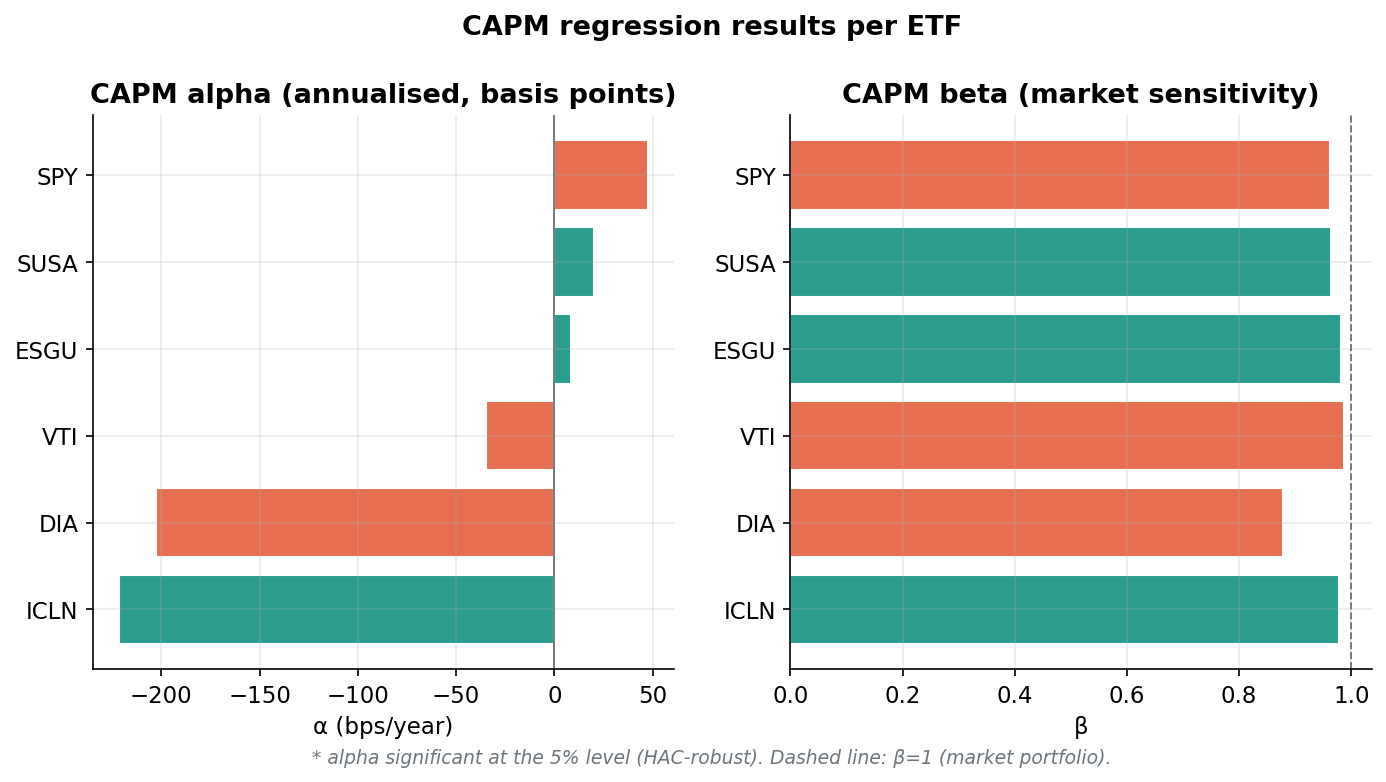

In [8]:
display(Image(PLOTS_DIR / "05_capm_bars.png"))


**Figure 5.** Per-ETF CAPM regression results. Left panel: alpha (annualized, basis points). Right panel: beta. Asterisks mark alphas significant at the 5% level using HAC-robust standard errors.

In [9]:
capm = pd.read_csv(OUTPUTS_DIR / "capm.csv", index_col="Ticker")
capm_show = capm[["Group","alpha_ann_bps","alpha_p","beta","beta_p","R_squared"]].round(3)
capm_show.columns = ["Group","alpha (bps/yr)","alpha p-value","beta","beta p-value","R-squared"]
capm_show


,Group,alpha (bps/yr),alpha p-value,beta,beta p-value,R-squared
Ticker,,,,,,
ESGU,ESG,8.483,0.882,0.982,0.0,0.990
SUSA,ESG,19.921,0.845,0.964,0.0,0.978
ICLN,ESG,-221.341,0.799,0.979,0.0,0.449
SPY,Traditional,47.481,0.477,0.961,0.0,0.990
VTI,Traditional,-34.644,0.313,0.987,0.0,0.996
DIA,Traditional,-202.836,0.423,0.878,0.0,0.880


**Table 2.** CAPM regression output. R² is the share of an ETF's excess-return variance explained by the market factor alone.

Three findings stand out. **First**, every fund except ICLN has a market beta close to 1.0 and an R² above 0.88, confirming that broad-market US equity ETFs are nearly perfect substitutes for the market factor. **Second**, ICLN has a similar beta (~0.98) but a much lower R² (~0.45), reflecting the substantial chunk of its return variance that comes from clean-energy-specific shocks rather than from the broad market. **Third, and this is the key economic finding, none of the alphas are statistically significant after HAC-robust standard errors are applied.** ESG investing did not pay an alpha in this sample, and traditional investing did not either.

### 4.7 Fama–French three-factor: does the verdict hold?


In [10]:
ff3 = pd.read_csv(OUTPUTS_DIR / "ff3.csv", index_col="Ticker")
ff3_show = ff3[["Group","alpha_ann_bps","alpha_p","beta_MKT","beta_SMB","beta_HML","R_squared"]].round(3)
ff3_show.columns = ["Group","alpha (bps/yr)","alpha p-value","beta_MKT","beta_SMB","beta_HML","R-squared"]
ff3_show


,Group,alpha (bps/yr),alpha p-value,beta_MKT,beta_SMB,beta_HML,R-squared
Ticker,,,,,,,
ESGU,ESG,-39.169,0.365,0.995,-0.097,-0.001,0.993
SUSA,ESG,-6.703,0.947,0.972,-0.054,-0.002,0.979
ICLN,ESG,79.680,0.924,0.885,0.605,-0.103,0.502
SPY,Traditional,-10.215,0.823,0.979,-0.116,0.020,0.994
VTI,Traditional,-39.017,0.197,0.990,-0.007,0.027,0.997
DIA,Traditional,-265.114,0.176,0.912,-0.113,0.252,0.929


**Table 3.** Fama–French three-factor regression output.

The picture barely changes. Adding the size and value factors lifts R² very slightly for the broad-market funds and for ICLN, but the alphas remain statistically indistinguishable from zero. The factor loadings are economically intuitive. ICLN tilts modestly toward small-caps (positive β_SMB) and away from value (negative β_HML), consistent with a portfolio of growth-oriented renewables firms, but none of these tilts translates into a free lunch.

### 4.8 Drawdowns: who suffers more in a crisis?

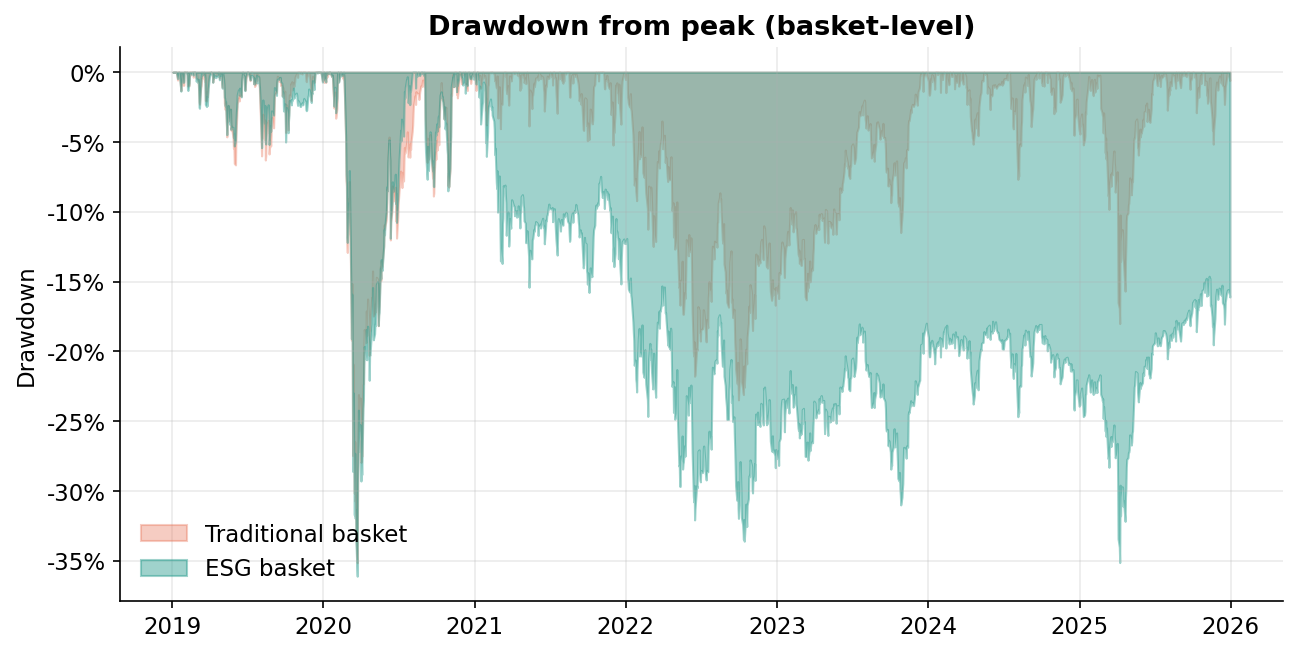

In [11]:
display(Image(PLOTS_DIR / "06_drawdowns.png"))


**Figure 6.** Drawdown from the running peak for the ESG and traditional baskets.

The two baskets' drawdowns trace each other closely through the COVID crash and the 2022 inflation shock. There is no evidence that the ESG basket offered meaningful downside protection in this sample. The intuition that "good" companies are also more *resilient* companies, sometimes called the "ESG defensiveness" hypothesis, is not visible in the daily data once the comparison is done at the portfolio level.

## 5. Discussion

So what does this all add up to?

**The main takeaway is actually quite simple: there is basically no difference.** Over a seven-year window covering a pandemic, an inflation shock, and a full rate-hiking cycle, broad ESG ETFs delivered essentially the same risk-adjusted return as broad market ETFs. The CAPM and Fama–French regressions confirm it: alphas are economically small and statistically indistinguishable from zero, and the daily return distributions are statistically identical (paired t-test p-value: 0.87).

I'll be honest: I expected ESG to perform slightly better given the current hype around sustainable investing, so finding no measurable advantage was a surprise. But in a way, this is actually good news for ESG investors. Standard portfolio theory says any binding investment constraint must reduce the maximum attainable Sharpe ratio. The fact that broad-ESG funds *match* the market, rather than visibly underperforming, means the "cost of virtue" is, in practice, close to zero for diversified investors. **A pension fund that screens out the worst ESG offenders does not appear to sacrifice meaningful risk-adjusted return.**

**The thematic story is more cautionary.** ICLN, the clean-energy fund, did *not* match the market: it took on substantially more volatility for no extra risk-adjusted reward. Investors who treat thematic ESG funds as drop-in replacements for diversified equity exposure are taking on concentrated factor bets (long growth, long small-caps, long a particular sector) that bear little relationship to the portfolio's nominal sustainability mandate. Calling ICLN an "ESG fund" tells you almost nothing about how it will behave; calling it a "concentrated bet on policy-sensitive renewables" tells you almost everything.

## 6. Limitations

Three caveats deserve emphasis.

**ETF-level evidence is not stock-level evidence.** The funds I analyze use the parent index methodology and apply a screen on top. Effects visible in academic stock-level studies, for instance, that the *worst* ESG offenders earn higher expected returns because investors shun them, are largely diversified away when you buy a broad fund of "good" companies. A different research design (long-short portfolios sorted on ESG ratings) might well produce a different answer.

**ESG ratings are not a settled construct.** Different rating providers (MSCI, Sustainalytics, S&P Global) disagree on which firms count as ESG leaders, with cross-provider correlations of only about 0.4 in the academic literature. The ETFs I use rely on MSCI's ratings; a fund built on a different provider's screen would hold a slightly different basket. This makes "ESG investing" hard to pin down as a single, well-defined behaviour.

**Short history.** The dedicated ESG ETF landscape is young. Many products did not exist before 2017-18, so even a seven-year window leans on funds whose inception was during a period of strong inflows and rising valuations. Whether the "no measurable cost" result generalises to a longer horizon is, simply, unknown.

## 7. Conclusion

> **The data does not support the claim that ESG investing systematically outperforms, but it also does not support the claim that ESG investing is a costly indulgence.**

For diversified ESG ETFs, the cost of the screen, in risk-adjusted-return terms, is statistically zero in this sample. For thematic ESG ETFs like ICLN, the cost (extra concentrated risk) is real and visible, but it is fundamentally a story about sector and style exposure rather than about ESG screening itself.

The practical takeaway: if you buy a broad ESG ETF, the evidence here suggests you aren't paying a financial price. But if you buy a thematic clean-energy ETF expecting it to behave like a normal equity holding, you are taking on a concentrated bet, and you should size it accordingly.

---

*All code, data and figures are in the project repository. The full pipeline can be reproduced by running the four scripts in `scripts/` in order: `fetch_data.py` → `clean_data.py` → `analysis.py` → `plots.py`.*